In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Data Loading and Initial Exploration

The first step is to load the lead dataset and inspect its structure. This allows us to verify the available columns, identify potential data quality issues, and understand how lead outcomes are recorded.

Key objectives:
- Load the dataset into a pandas DataFrame
- Review column names and data types
- Confirm row counts and overall dataset size
- Identify fields relevant to lead quality analysis

In [65]:
# Load data
file_path = "Data/Analyst_case_study_dataset_1_(1).xls"   

df = pd.read_excel(file_path)

df.head()

,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,...,Partner,ReferralDomain,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0,...,google,www.google.com,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,...,AdKnowledge,NaN,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,...,AdKnowledge,us.mc582.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
3,2009-08-03 19:39:02.000,Kari,usa4ley@yahoo.com,jB01QgYZxkWArI9jWxuufw,Contacted - Doesn't Qualify,w-302252-DebtReduction1-1DC-white,TopLeft-302252,DebtReductionInc,5.0,3.0,...,Google,norwich.kijiji.com,DebtReductionInc,Lower Payments,NaN,NaN,http://norwich.kijiji.com/c-Cars-vehicles-Cars...,NaN,http://www.debtreductioninc.com/index12.html,utm_source=Google&utm_medium=cpc&utm_campaign=...
4,2009-04-13 10:18:37.490,Stephanie,sr1lambert@embarqmail.com,D5B32074-458E-40EC-B185-1FEF20AC626D,NaN,w-300250-DebtReduction1-1DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,...,Google,NaN,DebtReductionInc,Debt Reduction,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=Google&utm_medium=cpc&utm_campaign=...


In [66]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns

Index(['LeadCreated', 'FirstName', 'Email', 'VendorLeadID', 'CallStatus',
       'WidgetName', 'PublisherZoneName', 'PublisherCampaignName',
       'AddressScore', 'PhoneScore', 'AdvertiserCampaignName', 'State',
       'DebtLevel', 'IP_Address', 'Partner', 'ReferralDomain',
       'MarketingCampaign', 'AdGroup', 'Keyword', 'SearchQuery', 'ReferralURL',
       'ReferralURL_Parameters', 'LandingPageURL',
       'Landing_Page_URL_Parameters'],
      dtype='object')

# Data Cleaning and Feature Engineering

Before analysis, the dataset requires standardization of column names and creation of lead quality indicators.

Based on the advertiser's definitions:

Good Lead Outcomes:
- Closed
- EP Sent
- EP Received
- EP Confirmed

Bad Lead Outcomes:
- Unable to Contact
- Contacted - Invalid Profile
- Contacted - Doesn't Qualify

Unknown Outcomes:
- All remaining statuses

Binary indicators are created to support statistical analysis and segmentation.

In [67]:
df["CallStatus_clean"] = df["CallStatus"].fillna("Unknown").str.strip()

good_status = [
    "Closed",
    "EP Sent",
    "EP Received",
    "EP Confirmed"
]

bad_status = [
    "Unable to contact - Bad Contact Information",
    "Contacted - Invalid Profile",
    "Contacted - Doesn't Qualify"
]

df["is_good"] = df["CallStatus_clean"].isin(good_status).astype(int)
df["is_closed"] = (df["CallStatus_clean"] == "Closed").astype(int)
df["is_bad"] = df["CallStatus_clean"].isin(bad_status).astype(int)
df["is_unknown"] = (~df["is_good"].astype(bool) & ~df["is_bad"].astype(bool)).astype(int)

# Overall Lead Quality Performance

This section establishes baseline performance across the entire dataset.

Metrics:
- Total Leads
- Good Leads
- Closed Leads
- Bad Leads
- Quality Rate
- Closed Rate

These metrics serve as benchmarks when evaluating individual segments later in the analysis.

In [68]:
# Overall lead quality
overall = pd.DataFrame({
    "total_leads": [len(df)],
    "good_leads": [df["is_good"].sum()],
    "closed_leads": [df["is_closed"].sum()],
    "bad_leads": [df["is_bad"].sum()],
    "unknown_leads": [df["is_unknown"].sum()],
    "quality_rate": [df["is_good"].mean()],
    "closed_rate": [df["is_closed"].mean()]
})

overall

,total_leads,good_leads,closed_leads,bad_leads,unknown_leads,quality_rate,closed_rate
0,3021,393,245,488,2140,0.130089,0.081099


# Lead Quality Trend Analysis

To determine whether lead quality is improving or declining over time, leads are aggregated by week.

Metrics tracked:
- Weekly Lead Volume
- Weekly Quality Rate
- Weekly Closed Rate

The advertiser is primarily interested in lead quality improvements, so trend analysis helps identify whether performance is moving toward or away from business objectives.

In [69]:
# Trend over time by week
df["week"] = df["LeadCreated"].dt.to_period("W").dt.start_time

weekly = (
    df.groupby("week")
    .agg(
        leads=("VendorLeadID", "count"),
        good_leads=("is_good", "sum"),
        closed_leads=("is_closed", "sum"),
        bad_leads=("is_bad", "sum")
    )
    .reset_index()
)

weekly["quality_rate"] = weekly["good_leads"] / weekly["leads"]
weekly["closed_rate"] = weekly["closed_leads"] / weekly["leads"]

weekly

,week,leads,good_leads,closed_leads,bad_leads,quality_rate,closed_rate
0,2009-03-30,37,6,3,3,0.162162,0.081081
1,2009-04-06,119,18,15,9,0.151261,0.126050
2,2009-04-13,125,21,16,10,0.168000,0.128000
3,2009-04-20,154,25,14,22,0.162338,0.090909
4,2009-04-27,129,14,10,14,0.108527,0.077519
5,2009-05-04,113,13,10,10,0.115044,0.088496
6,2009-05-11,165,21,12,20,0.127273,0.072727
7,2009-05-18,122,11,8,11,0.090164,0.065574
8,2009-05-25,132,9,5,15,0.068182,0.037879
9,2009-06-01,137,14,10,30,0.102190,0.072993


## Weekly Lead Quality Trend

This chart shows how lead quality and closed rates changed over time.  
The dashed horizontal line represents the advertiser's target quality rate of 9.6%.

This helps determine whether lead quality is moving toward the advertiser's proposed CPL increase target.

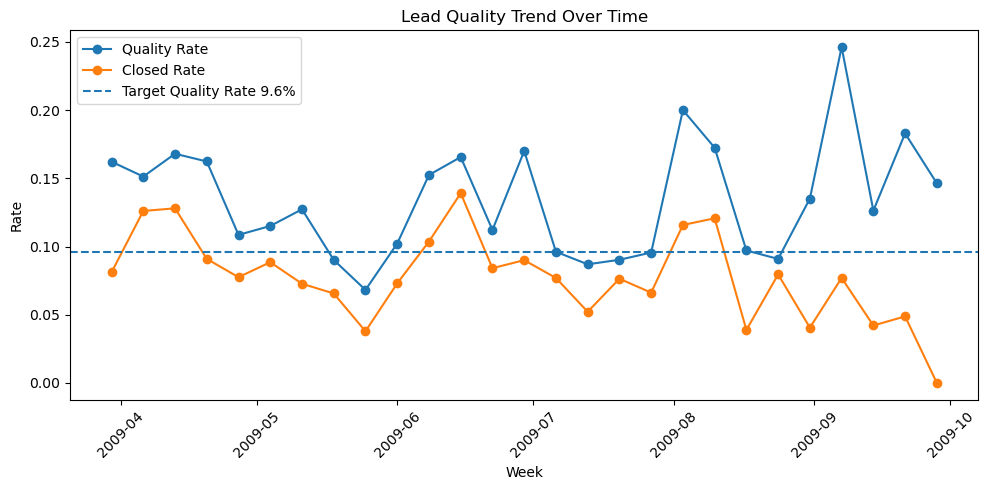

In [70]:
plt.figure(figsize=(10,5))

x = weekly["week"].to_numpy()
quality = weekly["quality_rate"].to_numpy()
closed = weekly["closed_rate"].to_numpy()

plt.plot(x, quality, marker="o", label="Quality Rate")
plt.plot(x, closed, marker="o", label="Closed Rate")

plt.axhline(y=0.096, linestyle="--", label="Target Quality Rate 9.6%")

plt.title("Lead Quality Trend Over Time")
plt.xlabel("Week")
plt.ylabel("Rate")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Question 1: Is Lead Quality Improving Over Time?**

## Statistical Test for Time Trends

Visual trends can sometimes be misleading. To determine whether lead quality is truly improving or declining, a logistic regression model is fitted using lead quality as the outcome variable and lead creation date as the predictor.

Interpretation:
- Positive coefficient = improving quality
- Negative coefficient = declining quality
- p-value < 0.05 = statistically significant

In [71]:
trend_df = df.dropna(subset=["LeadCreated"]).copy()

trend_df["date_num"] = (
    trend_df["LeadCreated"]
    - trend_df["LeadCreated"].min()
).dt.days

model = smf.logit(
    "is_good ~ date_num",
    data=trend_df
).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.386545
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                is_good   No. Observations:                 3021
Model:                          Logit   Df Residuals:                     3019
Method:                           MLE   Df Model:                            1
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:               3.030e-05
Time:                        17:46:39   Log-Likelihood:                -1167.8
converged:                       True   LL-Null:                       -1167.8
Covariance Type:            nonrobust   LLR p-value:                    0.7902
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9242      0.105    -18.263      0.000      -2.131      -1.718
date_num       0.0003      0.001      0.266      0.790      -0.002       0.002
==============================================================================
"""

In [72]:
coef = model.params["date_num"]
pval = model.pvalues["date_num"]

print("Coefficient:", round(coef,6))
print("P-value:", round(pval,6))

if pval < 0.05:
    if coef > 0:
        print("Lead quality is improving over time.")
    else:
        print("Lead quality is declining over time.")
else:
    print("No statistically significant trend detected.")

Coefficient: 0.000289
P-value: 0.79015
No statistically significant trend detected.


**Question 2: What Drives Lead Quality?**

## Segment Analysis

Lead quality may vary across different traffic sources, creative designs, customer characteristics, and campaigns.

The analysis below evaluates quality rates across key dimensions and identifies segments that outperform the overall average.

In [73]:
def segment_quality(df, col, min_leads=30):
    
    result = (
        df.groupby(col)
        .agg(
            leads=("VendorLeadID","count"),
            good_leads=("is_good","sum"),
            closed_leads=("is_closed","sum")
        )
        .reset_index()
    )

    result["quality_rate"] = (
        result["good_leads"] / result["leads"]
    )

    result["closed_rate"] = (
        result["closed_leads"] / result["leads"]
    )

    overall_quality = df["is_good"].mean()

    result["lift_vs_avg"] = (
        result["quality_rate"] / overall_quality - 1
    )

    return (
        result[result["leads"] >= min_leads]
        .sort_values("quality_rate", ascending=False)
    )

### Widget Performance

WidgetName represents different creative designs and layouts shown to users.

If certain creatives consistently generate higher quality leads, traffic can be shifted toward those designs.

In [74]:
widget_results = segment_quality(
    df,
    "WidgetName"
)

widget_results.head(20)

,WidgetName,leads,good_leads,closed_leads,quality_rate,closed_rate,lift_vs_avg
11,w-302252-DebtReduction1-1DC-yellowarrow,49,12,3,0.244898,0.061224,0.882536
2,w-300250-DebtReduction1-1DC-CreditSolutions,76,18,12,0.236842,0.157895,0.820611
0,w-300250-DebtReduction1-1DC,348,56,34,0.160920,0.097701,0.236992
3,w-300250-DebtReduction1-1DC-Head2,89,14,11,0.157303,0.123596,0.209195
1,w-300250-DebtReduction1-1DC-BlueMeter,92,14,13,0.152174,0.141304,0.169764
6,w-300250-DebtReduction1-2DC-BlueMeter,87,12,6,0.137931,0.068966,0.060279
12,w-302252-DebtReduction1-1DC-yellowarrow-blue,230,31,15,0.134783,0.065217,0.036077
9,w-302252-DebtReduction1-1DC-CreditSolutions,1052,131,76,0.124525,0.072243,-0.042776
8,w-302252-DebtReduction1-1DC,271,32,23,0.118081,0.084871,-0.092307
13,w-302252-DebtReduction1-1DC-yellowarrow-dark,135,15,10,0.111111,0.074074,-0.145886


### Campaign Performance

Campaign-level analysis helps identify which acquisition channels generate the highest quality leads.

In [75]:
campaign_results = segment_quality(
    df,
    "MarketingCampaign"
)

campaign_results.head(20)

,MarketingCampaign,leads,good_leads,closed_leads,quality_rate,closed_rate,lift_vs_avg
17,Financial Services,171,32,21,0.187135,0.122807,0.438507
5,Debt Holding Tank,337,61,49,0.181009,0.145401,0.391420
7,Debt Volume,143,23,13,0.160839,0.090909,0.236374
0,Credit,100,14,12,0.140000,0.120000,0.076183
18,state,97,12,10,0.123711,0.103093,-0.049028
3,Debt Consolidation,34,4,1,0.117647,0.029412,-0.095644
11,DebtReductionInc,1468,166,88,0.113079,0.059946,-0.130759
4,Debt General,328,29,20,0.088415,0.060976,-0.320355


### Geographic Performance

Lead quality may vary by state due to differences in consumer behavior, qualification requirements, or debt characteristics.

In [76]:
state_results = segment_quality(
    df,
    "State"
)

state_results.head(20)

,State,leads,good_leads,closed_leads,quality_rate,closed_rate,lift_vs_avg
24,OK,50,13,9,0.260000,0.180000,0.998626
9,HI,32,7,5,0.218750,0.156250,0.681536
14,MA,70,12,4,0.171429,0.057143,0.317775
1,AL,95,16,12,0.168421,0.126316,0.294656
4,CA,462,73,44,0.158009,0.095238,0.214616
31,WV,52,8,5,0.153846,0.096154,0.182619
25,OR,53,8,3,0.150943,0.056604,0.160305
3,AZ,94,14,9,0.148936,0.095745,0.144876
22,NV,54,8,5,0.148148,0.092593,0.138818
29,VA,145,21,12,0.144828,0.082759,0.113293


### Address Verification Quality

AddressScore measures how closely the submitted address matches external records.

Higher scores may indicate more trustworthy lead information.

In [77]:
address_results = segment_quality(
    df,
    "AddressScore",
    min_leads=20
)

address_results

,AddressScore,leads,good_leads,closed_leads,quality_rate,closed_rate,lift_vs_avg
1,2.0,38,7,4,0.184211,0.105263,0.416031
4,5.0,868,120,64,0.138249,0.073733,0.062722
0,1.0,122,14,5,0.114754,0.040984,-0.117883
2,3.0,93,9,5,0.096774,0.053763,-0.256095
3,4.0,48,2,1,0.041667,0.020833,-0.679707


In [78]:
phone_results = segment_quality(
    df,
    "PhoneScore",
    min_leads=20
)

phone_results

,PhoneScore,leads,good_leads,closed_leads,quality_rate,closed_rate,lift_vs_avg
4,5.0,619,100,54,0.161551,0.087237,0.241845
2,3.0,426,50,28,0.117371,0.065728,-0.097767
1,2.0,160,16,7,0.100000,0.043750,-0.231298
3,4.0,184,13,7,0.070652,0.038043,-0.456895


### Debt Level Analysis

Consumers with higher debt levels may be more likely to qualify for debt relief programs.

Debt levels are grouped into ranges for comparison.

In [79]:
df["DebtLevel"].value_counts(dropna=False).head(20)

debt_results = segment_quality(
    df,
    "DebtLevel",
    min_leads=20
)

debt_results

,DebtLevel,leads,good_leads,closed_leads,quality_rate,closed_rate,lift_vs_avg
5,70001-90000,131,25,18,0.190840,0.137405,0.466989
0,10001-15000,291,54,34,0.185567,0.116838,0.426458
2,20001-30000,454,72,40,0.158590,0.088106,0.219087
4,50001-70000,244,38,22,0.155738,0.090164,0.197159
1,15001-20000,408,57,35,0.139706,0.085784,0.073922
3,30001-50000,495,61,39,0.123232,0.078788,-0.052710
8,90000-100000,90,11,9,0.122222,0.100000,-0.060475
7,7500-15000,270,31,19,0.114815,0.070370,-0.117416
6,7500-10000,440,31,22,0.070455,0.050000,-0.458414
9,More_than_100000,190,13,7,0.068421,0.036842,-0.474046


**Question 3: Can We Reach 9.6% Quality?**

## Opportunity Analysis

The advertiser's proposed target is a 9.6% quality rate. In this dataset, the current observed quality rate is 13.0%, which is already above the target. Therefore, the bigger opportunity is not simply reaching the target, but identifying which segments can preserve or improve quality while scaling volume.


In [80]:
target_rate = 0.096

candidate_cols = [
    "WidgetName",
    "MarketingCampaign",
    "PublisherCampaignName",
    "AdvertiserCampaignName",
    "PublisherZoneName",
    "State",
    "AddressScore",
    "PhoneScore",
    "DebtLevel",
    "Partner",
    "ReferralDomain",
    "AdGroup",
    "Keyword"
]

opportunities = []

for column in candidate_cols:
    if column in df.columns:
        temp = segment_quality(df, column, min_leads=30).copy()
        temp = temp[temp["quality_rate"] >= target_rate].copy()
        
        temp["segment_type"] = column
        temp = temp.rename(columns={column: "segment_value"})
        
        opportunities.append(
            temp[[
                "segment_type",
                "segment_value",
                "leads",
                "good_leads",
                "closed_leads",
                "quality_rate",
                "closed_rate",
                "lift_vs_avg"
            ]]
        )

opportunity_df = pd.concat(opportunities, ignore_index=True)

opportunity_df.sort_values(
    ["quality_rate", "leads"],
    ascending=[False, False]
).head(30)

,segment_type,segment_value,leads,good_leads,closed_leads,quality_rate,closed_rate,lift_vs_avg
25,State,OK,50,13,9,0.260000,0.180000,0.998626
0,WidgetName,w-302252-DebtReduction1-1DC-yellowarrow,49,12,3,0.244898,0.061224,0.882536
1,WidgetName,w-300250-DebtReduction1-1DC-CreditSolutions,76,18,12,0.236842,0.157895,0.820611
69,AdGroup,Debt Negotiation,35,8,6,0.228571,0.171429,0.757034
26,State,HI,32,7,5,0.218750,0.156250,0.681536
82,Keyword,Debt,92,20,11,0.217391,0.119565,0.671092
70,AdGroup,Debt,93,20,11,0.215054,0.118280,0.653123
71,AdGroup,Stop Collections,53,11,8,0.207547,0.150943,0.595420
64,ReferralDomain,search.aol.com,46,9,6,0.195652,0.130435,0.503983
52,DebtLevel,70001-90000,131,25,18,0.190840,0.137405,0.466989
